Importing Libraries and modules:

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


Loading data:

In [3]:
data=pd.read_csv('/content/spam.csv')
df=data.copy()
df.head(4)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...


In [4]:
df.shape

(5572, 2)

In [5]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [6]:
df.isnull().sum()

,0
Category,0
Message,0


In [7]:
df.duplicated().sum()

np.int64(415)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [22]:
def clean_text(text_d):
  text_d=text_d.lower()
  text_d=re.sub('\[.*?\]'," ",text_d)
  text_d=re.sub('[^0-9a-zA-Z]'," ",text_d)
  text_d=text_d.strip()
  text_d=re.sub(r'\d+','',text_d)
  text_d = re.sub('\s+', ' ', text_d)
  return text_d

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-191894984.py:3: SyntaxWarning: invalid escape sequence '\['
  text_d=re.sub('\[.*?\]'," ",text_d)
/tmp/ipython-input-191894984.py:7: SyntaxWarning: invalid escape sequence '\s'
  text_d = re.sub('\s+', ' ', text_d)


In [23]:
df['Message'] = df['Message'].apply(clean_text)
display(df.head())

,Category,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i don t think he goes to usf he lives arou...


In [24]:
df['Category']=df['Category'].map({'spam':1,'ham':0})
df.head(4)


,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final ...
3,0,u dun say so early hor u c already then say


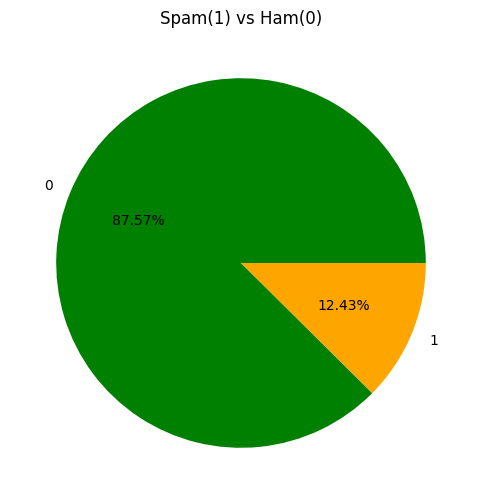

In [55]:
plt.figure(figsize=(6,6))
plt.pie(df['Category'].value_counts(),labels=df['Category'].value_counts().index,colors=['green','orange'],autopct='%1.2f%%')
plt.title('Spam(1) vs Ham(0)')
plt.show()

Text(0.5, 1.0, 'Count plot')

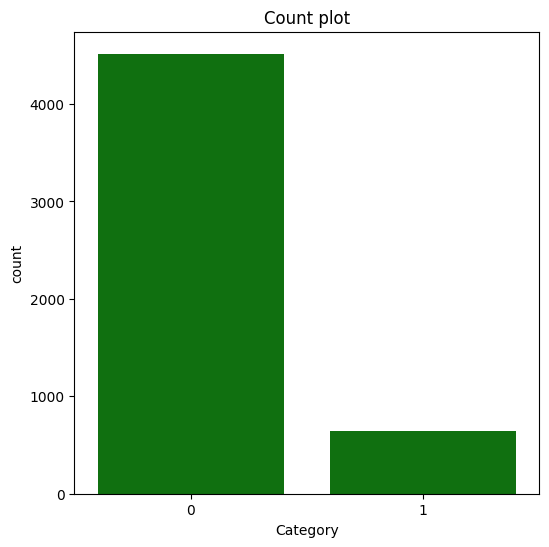

In [59]:
plt.figure(figsize=(6,6))
sns.countplot(x=df['Category'],data=df,color='green')
plt.title('Count plot')

In [33]:
vectorizer=CountVectorizer()


In [34]:
df.shape

(5157, 2)

In [35]:
X=vectorizer.fit_transform(df['Message'])
y=df['Category']

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((4125, 7817), (1032, 7817))

In [37]:
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [40]:
y_predict_train=model.predict(X_train)
y_predict_tst=model.predict(X_test)

In [41]:
print('Evaluation:')
print('Accuracy on training data:',accuracy_score(y_train,y_predict_train))
print('Accuracy on testing data:',accuracy_score(y_test,y_predict_tst))

Evaluation:
Accuracy on training data: 0.9915151515151515
Accuracy on testing data: 0.9680232558139535


In [43]:
print('Classsification report')
print('Classification report on training data:\n',classification_report(y_train,y_predict_train))
print('Classification report on testing data:\n',classification_report(y_test,y_predict_tst))

Classsification report
Classification report on training data:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3620
           1       0.97      0.96      0.97       505

    accuracy                           0.99      4125
   macro avg       0.98      0.98      0.98      4125
weighted avg       0.99      0.99      0.99      4125

Classification report on testing data:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       896
           1       0.83      0.95      0.89       136

    accuracy                           0.97      1032
   macro avg       0.91      0.96      0.93      1032
weighted avg       0.97      0.97      0.97      1032



<Axes: title={'center': 'Confusion Matrix'}>

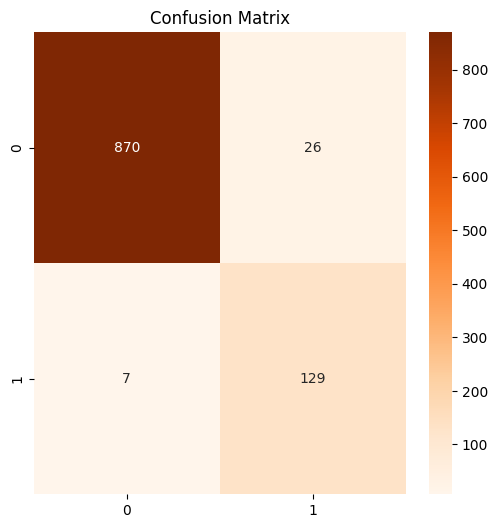

In [44]:
plt.figure(figsize=(6,6))
plt.title('Confusion Matrix')
sns.heatmap(confusion_matrix(y_test,y_predict_tst),annot=True,fmt='d',cmap="Oranges")